# Spectral Signature Analysis

Objective

Compare the hyperspectral signatures of representative coastal land-cover classes in Corozal, Belize using Planet Tanager imagery.

Land Cover Classes

- Clear Water
- Turbid Water
- Vegetation
- Agriculture
- Urban
- Cloud

In [1]:
%matplotlib widget

In [2]:
#1_Imports
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

DATA_PATH = Path(r"C:\GIS_Work\5 GeoSpectra AI\data\raw\20250824_171857_84_4001_ortho_sr_hdf5.h5")




In [3]:
#2_Load the cube values
with h5py.File(DATA_PATH, "r") as f:
    
    cube = f["HDFEOS/GRIDS/HYP/Data Fields/surface_reflectance"][:]
    
    wavelengths = f["HDFEOS/GRIDS/HYP/Data Fields/surface_reflectance"].attrs["wavelengths"]
    
fill_value = -9999.0

cube = cube.astype(np.float32)

cube[cube == fill_value] = np.nan

print(cube.shape)
print(f"Wavelengths:", len(wavelengths))

(426, 671, 763)
Wavelengths: 426


(671, 763, 3)
0.015855407 0.9574775
0.03221393 0.97651803
0.026197597 0.9587619
455 149
451 140
451 140


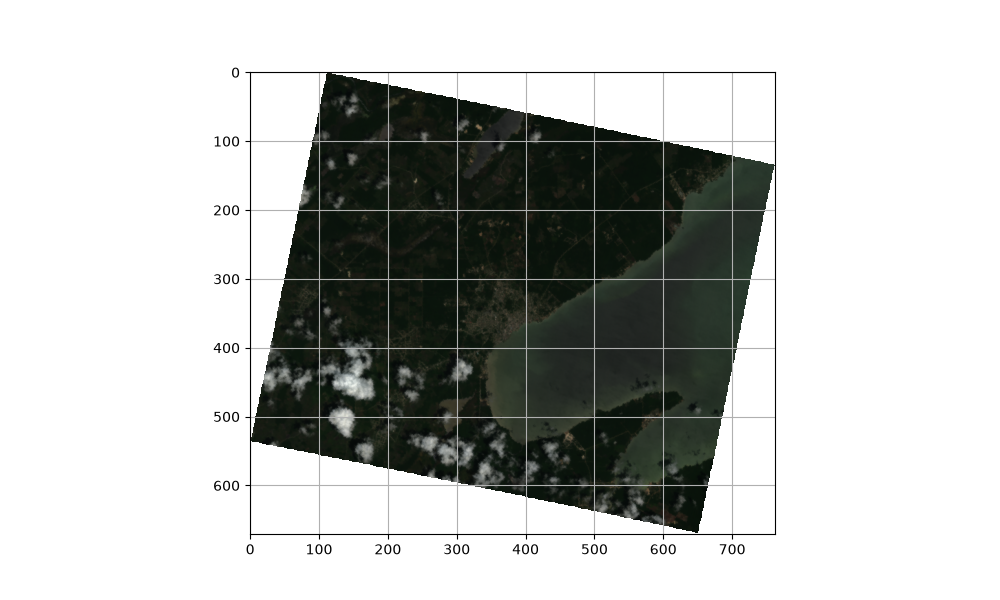

In [4]:
#3_Create RGB image
def find_band(target):
    return np.argmin(np.abs(wavelengths - target))

red = find_band(650)
green = find_band(550)
blue = find_band(470)

rgb = np.dstack([cube[red], cube[green], cube[blue]])
print(rgb.shape)
print(np.nanmin(cube[red]), np.nanmax(cube[red]))
print(np.nanmin(cube[green]), np.nanmax(cube[green]))
print(np.nanmin(cube[blue]), np.nanmax(cube[blue]))
row, col = np.unravel_index(np.nanargmax(cube[red]), cube[red].shape)
row1, col1 = np.unravel_index(np.nanargmax(cube[green]), cube[green].shape)
row2, col2 = np.unravel_index(np.nanargmax(cube[blue]), cube[blue].shape)
print(row, col)
print(row1, col1)
print(row2, col2)
plt.figure()
plt.imshow(rgb)
plt.show()

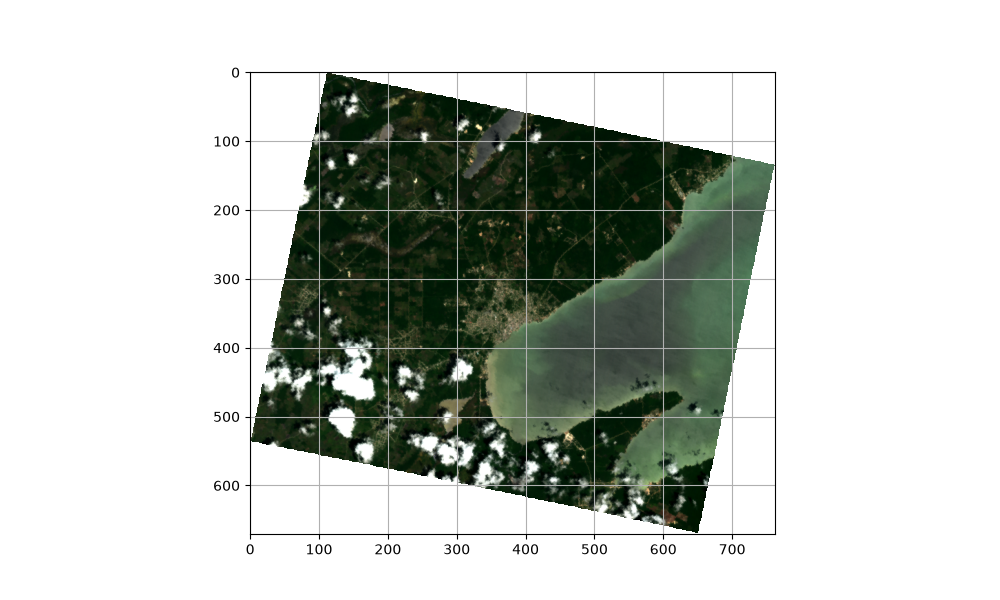

In [5]:
#4_Stretch Function and display rgb image
def stretch(image, lower=2, upper=98):
    image = image.copy()
    p2 = np.nanpercentile(image, lower)
    p98 = np.nanpercentile(image, upper)
    image = np.clip(image, p2, p98)
    image = (image - p2) / (p98 - p2)
    return image
rgb = np.dstack([cube[red], cube[green], cube[blue]])
rgb = stretch(rgb)
plt.figure()
plt.imshow(rgb)
plt.show()        

In [6]:
import matplotlib
print(matplotlib.get_backend())

widget


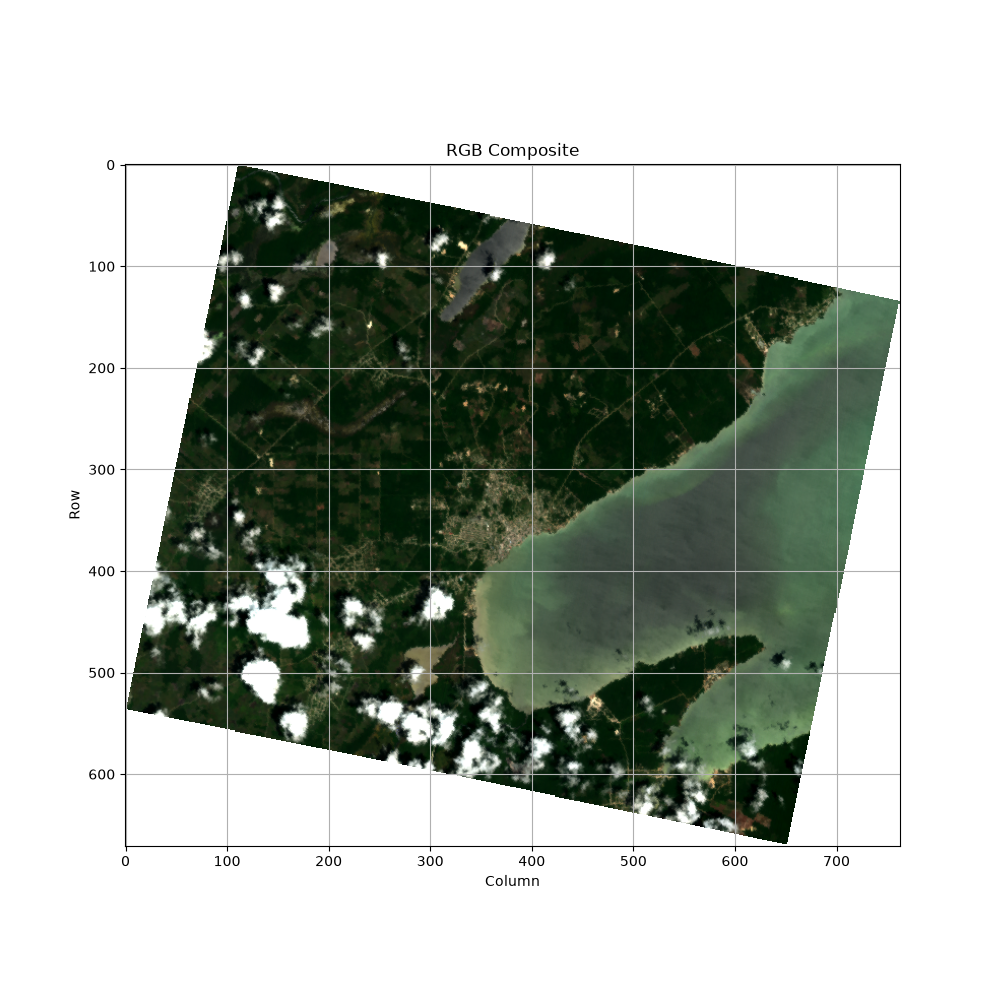

In [7]:
#5_Display RGB
plt.figure(figsize=(10,10))

plt.imshow(rgb)

plt.xlabel("Column")

plt.ylabel("Row")

plt.title("RGB Composite")

plt.grid(True)

plt.show()

In [8]:
#6_Sample locations
samples = {
    "Clear Water:":  (575, 453),
    "Turbid Water:": (380, 458),
    "Vegetation:":   (525, 175),
    "Agriculture:":  (183, 308),
    "Urban:":        (385, 367),
    "Cloud:":        (155, 460)
}

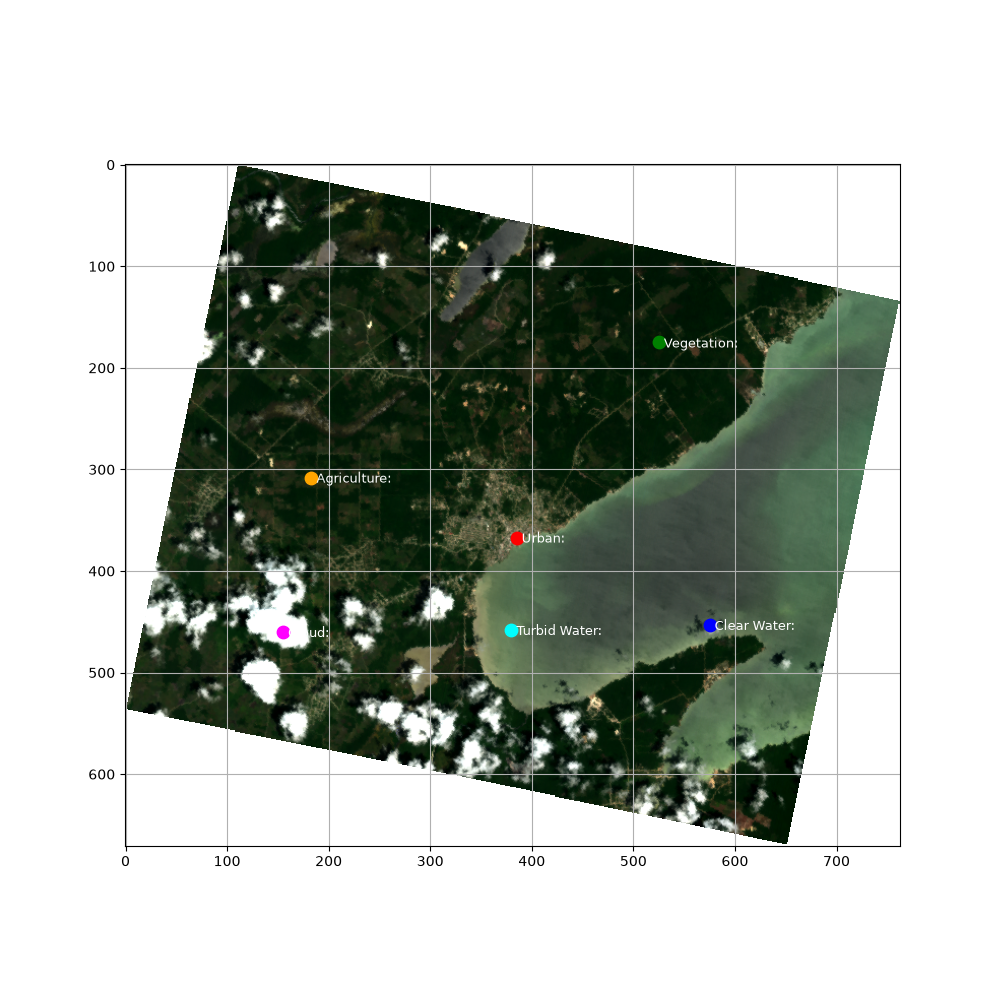

In [9]:
#7_Draw sample points on the image
fig, ax = plt.subplots(figsize=(10,10))
ax.imshow(rgb)

colors = ["blue", "cyan", "green", "orange", "red", "magenta"]

for(label, (x,y)), color in zip(samples.items(), colors):
    ax.scatter(x, y, color=color, s=80)
    ax.text(x+5, y+5, label, color="white", fontsize=9)

plt.show()

In [10]:
#8_Reusable extract function
def extract_mean_spectrum(cube, x, y, windows=5):
    half = windows // 2
    subset = cube[:, y-half:y+half+1, x-half:x+half+1]
    return np.nanmean(subset, axis=(1,2))

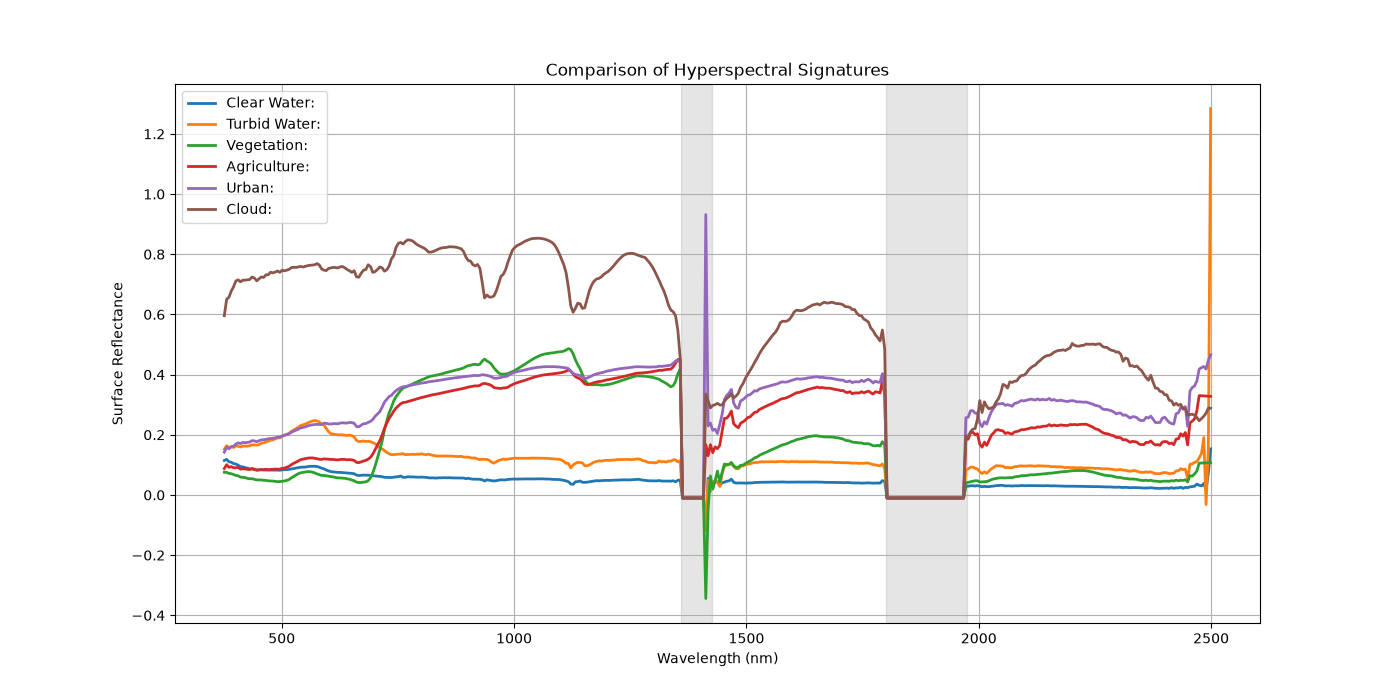

In [12]:
#9_Plot all spectra
plt.figure(figsize=(14,7))

for label,(x,y) in samples.items():

    spectrum = extract_mean_spectrum(cube, x, y, windows=5)

    plt.plot(
        wavelengths,
        spectrum,
        linewidth=2,
        label=label
    )

plt.xlabel("Wavelength (nm)")

plt.ylabel("Surface Reflectance")

plt.title("Comparison of Hyperspectral Signatures")

plt.legend()

plt.grid(True)

#10_Highlight atmospheric bands
plt.axvspan(1360,1425,
            color="gray",
            alpha=0.2)

plt.axvspan(1800,1975,
            color="gray",
            alpha=0.2)

plt.show()

In [13]:
#11_Save figure
from pathlib import Path

output = Path(r"C:\GIS_Work\5 GeoSpectra AI\outputs\figures")

output.mkdir(parents=True, exist_ok=True)

plt.savefig(output/"spectral_signatures.png", dpi=300, bbox_inches="tight")

Observations

- Vegetation exhibits strong NIR reflectance.
- Water maintains low reflectance.
- Turbid water has higher visible reflectance than clear water.
- Clouds are highly reflective.
- Atmospheric absorption bands are visible near 1400 and 1900 nm.